# Binomial Distribution
We will experiment with the distribution:
$$
  \mathrm{Binomial}(X; n, p) = \binom{n}{p}X^p(1-X)^{(1-p)}
$$

In [3]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

# parameters
n, p = 5, 0.4

# calculate mean / variance
mean = binom.mean(n, p)
var = binom.var(n, p)
print(f"Mean: {mean}, Var: {var}")

Mean: 2.0, Var: 1.1999999999999997


Text(0.5, 1.0, 'Binomial(n:5, p:0.4)')

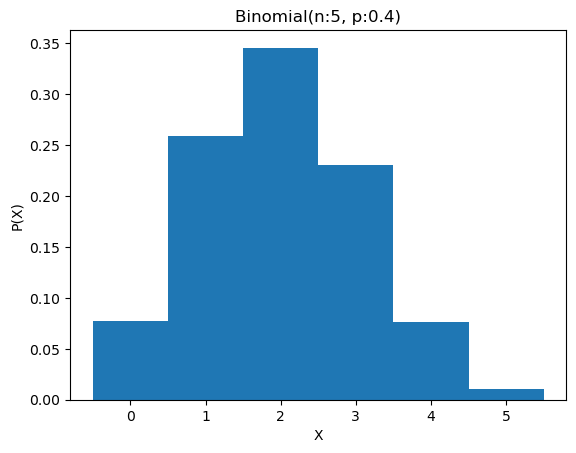

In [4]:
# plot PMF
fig, ax = plt.subplots(1, 1)
x = np.arange(n+1)
pmf = binom.pmf(x, n, p)
ax.bar(x, pmf, width=1.0)

# decorate plot
ax.set_xlabel("X")
ax.set_ylabel("P(X)")
ax.set_title(f"Binomial(n:{n}, p:{p})")

Text(0.5, 1.0, 'CDF: Binomial(n:5, p:0.4)')

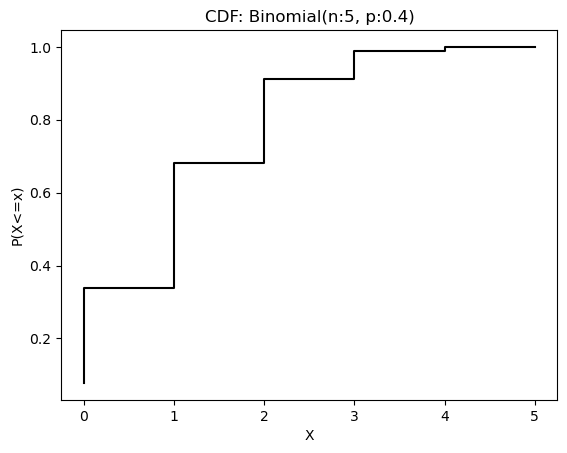

In [5]:
# plot CDF
fig, ax = plt.subplots(1, 1)
cdf = binom.cdf(x, n, p)
ax.step(x, cdf, '-k')

# decorate plot
ax.set_xlabel("X")
ax.set_ylabel("P(X<=x)")
ax.set_title(f"CDF: Binomial(n:{n}, p:{p})")

In [14]:
# sample 10 Binomial values
s = binom.rvs(n, p, size=10)
print(f"Sample: {s}")

Sample: [2 0 1 4 2 3 4 2 1 2]


----
# Multinomial Distribution
We will experiment with the distribution:
$$
  \mathrm{Multinomial}(X;n,p) = \frac{n!}{X_1!X_2!\ldots X_k!}p_1^{X_1}p_2^{X_2}\ldots p_k^{X_k}
$$

In [46]:
from scipy.stats import multinomial

# parameters
n = 10 # 10 rolls
p = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6] # fair 6-sided die

# calculate mean and covariance
mean = p
cov = multinomial.cov(n, p)
print(f"Mean: {mean}")

# plot covariance matrix
cell_text = []
print(f"Cov:")
for row in cov:
    print(['%1.1f' % v for v in row])


Mean: [0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]
Cov:
['1.4', '-0.3', '-0.3', '-0.3', '-0.3', '-0.3']
['-0.3', '1.4', '-0.3', '-0.3', '-0.3', '-0.3']
['-0.3', '-0.3', '1.4', '-0.3', '-0.3', '-0.3']
['-0.3', '-0.3', '-0.3', '1.4', '-0.3', '-0.3']
['-0.3', '-0.3', '-0.3', '-0.3', '1.4', '-0.3']
['-0.3', '-0.3', '-0.3', '-0.3', '-0.3', '1.4']


In [47]:
# simulate 10 rolls
x = multinomial.rvs(n, p)
print(f"Rolled x: {x}")

# compute probability of roll
pmf = multinomial.pmf(x, n, p)
print(f"P(X=x) = {pmf:0.5f}")

Rolled x: [2 2 3 3 0 0]
P(X=x) = 0.00042


----
# Negative Binomial Distribution
We will experiment with the distribution:
$$
  \mathrm{NB}(X;k,p) = \binom{X-1}{k-1}p^k(1-p)^{X-k}
$$

Text(0.5, 1.0, 'Negative Binomial PMF')

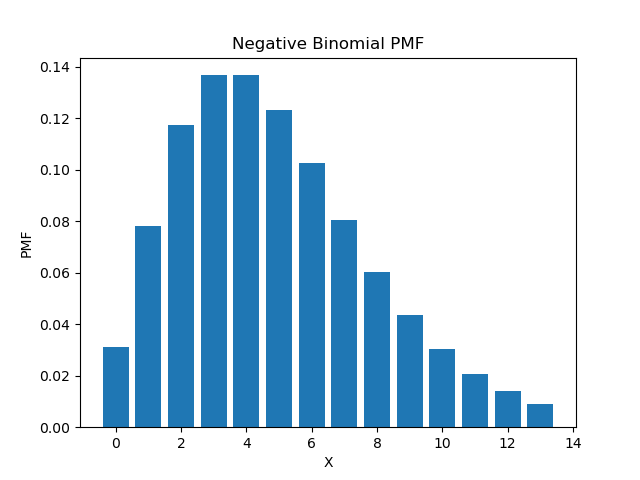

In [99]:
import numpy as np
from scipy.stats import nbinom
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)

# initialize parameters
n, p = 5, 0.5

# plot PMF
x = np.arange(nbinom.ppf(0.01, n, p),
              nbinom.ppf(0.99, n, p))
ax.bar(x, nbinom.pmf(x, n, p))
ax.set_xlabel('X')
ax.set_ylabel('PMF')
ax.set_title('Negative Binomial PMF')

Text(0.5, 1.0, 'Negative Binomial CDF')

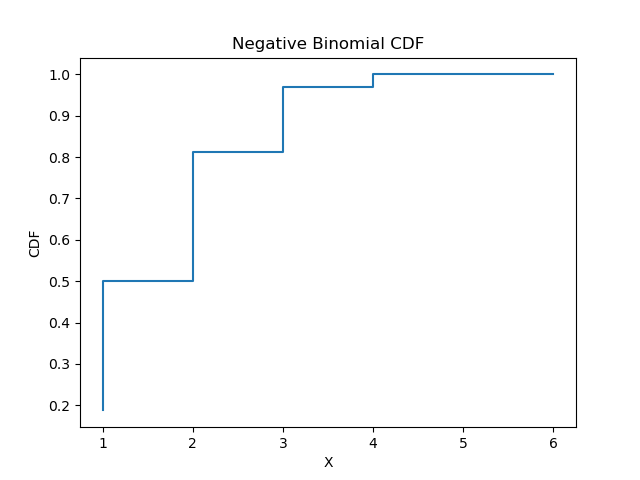

In [103]:
# plot CDF
fig, ax = plt.subplots(1, 1)
ax.step(x, binom.cdf(x, n, p))
ax.set_xlabel('X')
ax.set_ylabel('CDF')
ax.set_title('Negative Binomial CDF')

[1 3 1 1 2 4 5 2 3 3]


Text(0.5, 1.0, 'Geometric PMF')

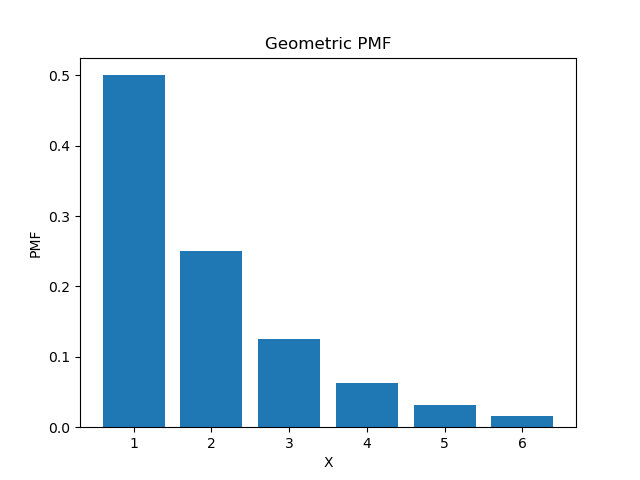

In [102]:
from scipy.stats import geom

# we can also work with the closely-related Geometric distribution

# sample 10 Geometric random variables
X = geom.rvs(p, size=10)
print(f"{X}")

# plot PMF
fig, ax = plt.subplots(1, 1)
x = np.arange(geom.ppf(0.01, p),
              geom.ppf(0.99, p))
ax.bar(x, geom.pmf(x, p))
ax.set_xlabel('X')
ax.set_ylabel('PMF')
ax.set_title('Geometric PMF')

----
# Poisson Distribution
We will experiment with the distribution:
$$
  \mathrm{Pois}(X;\lambda) = \frac{\lambda^X e^{-\lambda}}{X!}, \qquad \textrm{for}\, X = 0, 1, 2, \ldots
$$

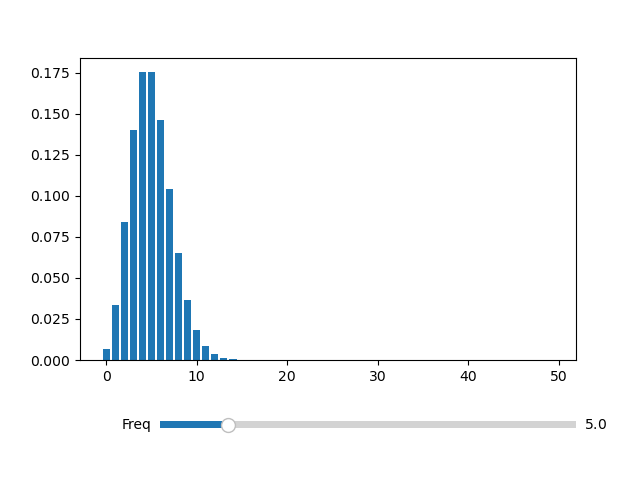

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.stats import poisson
%matplotlib ipympl

# callback function to update plot
def update(val):

    # recomput PMF
    lam = val
    pmf = poisson.pmf(x,lam)

    # update values one bar at a time
    for i, b in enumerate(bar_container):
        # Update the height of each bar based on the slider value
        b.set_height(pmf[i])
    
    # Redraw the figure to show changes
    fig.canvas.draw_idle()
    
# Show initial plot with lambda=5
x = np.arange(50)
fig, ax = plt.subplots()
bar_container = ax.bar(x, poisson.pmf(x,5), lw=2)
fig.subplots_adjust(bottom=0.25)

# Add slider
ax_freq = fig.add_axes([0.25, 0.1, 0.65, 0.03])
freq_slider = Slider(ax_freq, 'Freq', 0.1, 30.0, valinit=5)

# Update plot
freq_slider.on_changed(update)
plt.show()


# Poisson limit of the Binomial distribution
The binomial distribution converges towards the Poisson distribution as the number of trials goes to infinity while the product $np$ converges to a finite limit.  Consider the distribution $\textrm{Binomial}(X;n,p)$.  As $n\rightarrow \infty$ and $p \rightarrow 0$ it converges to a Poisson distribution with rate parameter $np \overset{n\rightarrow \infty}{\rightarrow} \lambda$.  Formally, we have that:
$$\textrm{Binomial}(x;,n,p) \overset{n \rightarrow \infty}{\rightarrow} \textrm{Poisson}(X;np).$$ 

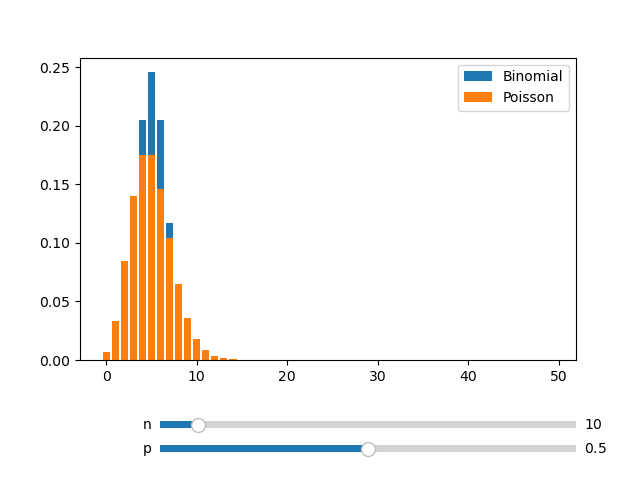

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.stats import poisson, binom
%matplotlib ipympl

# callback function to update plot
def update_n(val):

    # recompute PMF
    global n 
    n = val
    pmf_binom = binom.pmf(x,n,p)
    pmf_pois = poisson.pmf(x,n*p)

    # update binomial values one bar at a time
    for i, b in enumerate(bar_container_binom):
        # Update the height of each bar based on the slider value
        b.set_height(pmf_binom[i])

    # update poisson values one bar at a time
    for i, b in enumerate(bar_container_pois):
        # Update the height of each bar
        b.set_height(pmf_pois[i])    
    
    # Redraw the figure to show changes
    fig.canvas.draw_idle()

# callback function to update plot
def update_p(val):

    # recompute PMF
    global p 
    p = val
    pmf_binom = binom.pmf(x,n,p)
    pmf_pois = poisson.pmf(x,n*p)

    # update binomial values one bar at a time
    for i, b in enumerate(bar_container_binom):
        # Update the height of each bar based on the slider value
        b.set_height(pmf_binom[i])

    # update poisson values one bar at a time
    for i, b in enumerate(bar_container_pois):
        # Update the height of each bar
        b.set_height(pmf_pois[i]) 
    
    # Redraw the figure to show changes
    fig.canvas.draw_idle()

# initial n,p values
n = 10
p = 0.5
    
# Show initial plot with lambda=5
x = np.arange(50)
fig, ax = plt.subplots()
bar_container_binom = ax.bar(x, binom.pmf(x,n,p), lw=2, label="Binomial")
bar_container_pois = ax.bar(x, poisson.pmf(x,n*p), lw=2, label="Poisson")
ax.legend()
fig.subplots_adjust(bottom=0.25)

# Add slider
ax_n = fig.add_axes([0.25, 0.1, 0.65, 0.03])
ax_p = fig.add_axes([0.25, 0.05, 0.65, 0.03])
n_slider = Slider(ax_n, 'n', 1.0, 100.0, valinit=n, valstep=1.0)
p_slider = Slider(ax_p, 'p', 0.0, 1.0, valinit=p)

# Update plot
n_slider.on_changed(update_n)
p_slider.on_changed(update_p)
plt.show()